In [112]:
import pandas as pd

# Replace the path below with the actual location of your file
df = pd.read_csv('1000_ml_jobs_us.csv')

# Display the first 5 rows to confirm it's loaded
df.head()


,Unnamed: 0,job_posted_date,company_address_locality,company_address_region,company_name,company_website,company_description,job_description_text,seniority_level,job_title
0,0,2024-10-31,Indianapolis,Indiana,Upper Hand,https://upperhand.com,Upper Hand is the leading provider of full-sui...,OverviewUpper Hand is embarking on an exciting...,Internship,Internship - Machine Learning Engineer & Data ...
1,1,2025-03-14,San Francisco,California,Ikigai,https://www.ikigailabs.io,"Built upon years of MIT research, Ikigai is a ...",Company DescriptionThe Ikigai platform unlocks...,Mid-Senior level,Machine Learning Engineer
2,2,2025-04-09,San Jose,CA,Adobe,http://www.adobe.com,Adobe is the global leader in digital media an...,Our CompanyChanging the world through digital ...,Entry level,Machine Learning Engineer
3,3,2025-03-22,Mountain View,California,Waymo,https://waymo.com/careers/,On the journey to be the world's most trusted ...,Waymo is an autonomous driving technology comp...,Entry level,"Machine Learning Engineer, Training"
4,4,2025-03-28,Boston,Massachusetts,HMH,http://www.hmhco.com,We are an adaptive learning company that empow...,Job Title: Machine Learning EngineerLocation: ...,Mid-Senior level,Machine Learning Engineer


In [113]:
# Drop the unnamed index column
df.drop(columns=['Unnamed: 0'], inplace=True)

In [114]:
# Display shape and column info
print("Shape:", df.shape)


Shape: (997, 9)


In [115]:
print("\nColumn Info:")
print(df.info())


Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 997 entries, 0 to 996
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   job_posted_date           997 non-null    object
 1   company_address_locality  950 non-null    object
 2   company_address_region    884 non-null    object
 3   company_name              997 non-null    object
 4   company_website           983 non-null    object
 5   company_description       985 non-null    object
 6   job_description_text      996 non-null    object
 7   seniority_level           988 non-null    object
 8   job_title                 997 non-null    object
dtypes: object(9)
memory usage: 70.2+ KB
None


In [116]:


# Check for null values
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 job_posted_date               0
company_address_locality     47
company_address_region      113
company_name                  0
company_website              14
company_description          12
job_description_text          1
seniority_level               9
job_title                     0
dtype: int64


In [117]:
# Check unique values in seniority level and job title
print("\nSeniority Level Counts:\n", df['seniority_level'].value_counts())


Seniority Level Counts:
 seniority_level
Mid-Senior level    371
Entry level         300
Not Applicable      209
Internship           70
Associate            32
Director              5
Executive             1
Name: count, dtype: int64


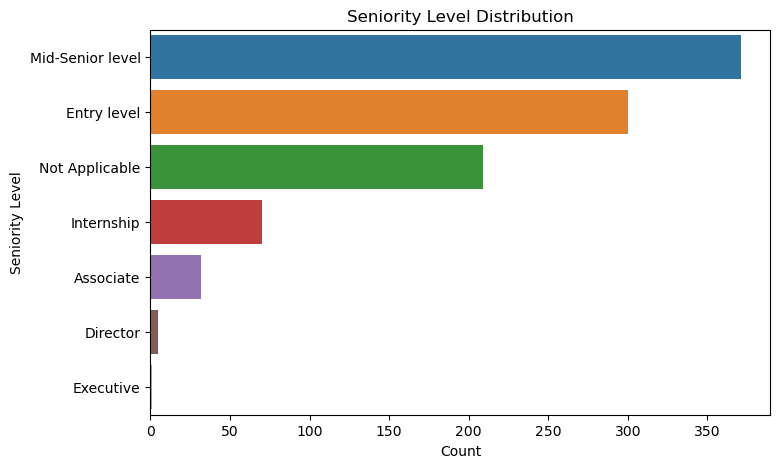

In [118]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(data=df, y='seniority_level', order=df['seniority_level'].value_counts().index)
plt.title('Seniority Level Distribution')
plt.xlabel('Count')
plt.ylabel('Seniority Level')
plt.show()


In [119]:
print("\nTop 3 Job Titles:\n", df['job_title'].value_counts().head(3))


Top 3 Job Titles:
 job_title
Machine Learning Engineer              243
Data Scientist                          53
Software Engineer, Machine Learning     30
Name: count, dtype: int64


In [120]:
# Top locations
print("\nTop Localities:\n", df['company_address_locality'].value_counts().head(3))


Top Localities:
 company_address_locality
San Francisco    148
Los Angeles       93
New York          54
Name: count, dtype: int64


In [121]:
print("\nTop Regions:\n", df['company_address_region'].value_counts().head(3))


Top Regions:
 company_address_region
California    308
CA            181
NY             34
Name: count, dtype: int64


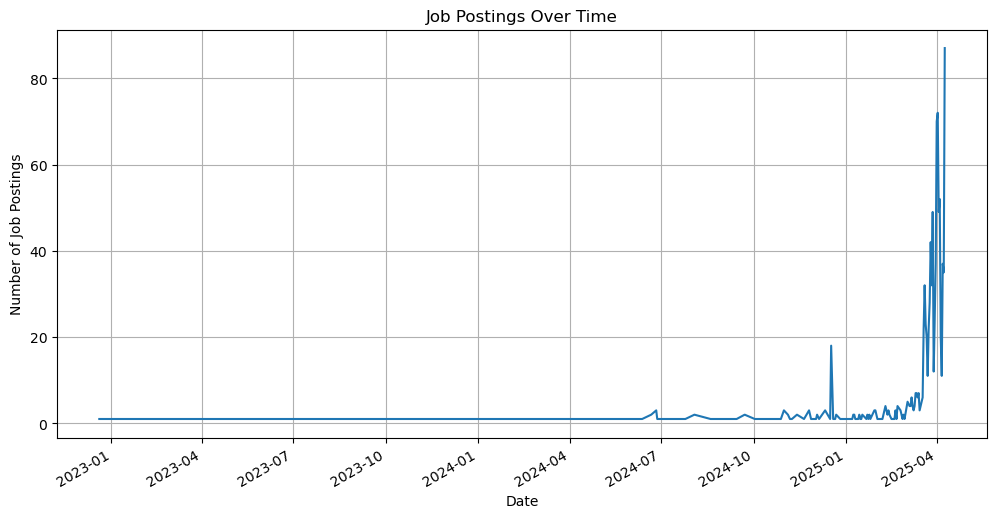

In [122]:
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
jobs_by_date = df['job_posted_date'].value_counts().sort_index()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
jobs_by_date.plot()
plt.title("Job Postings Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Job Postings")
plt.grid(True)
plt.show()


In [123]:
top_companies = df['company_name'].value_counts().head(5)
print("Top 10 Hiring Companies:\n", top_companies)


Top 10 Hiring Companies:
 company_name
TikTok       88
Meta         39
Snap Inc.    18
Adobe        18
Splunk       18
Name: count, dtype: int64


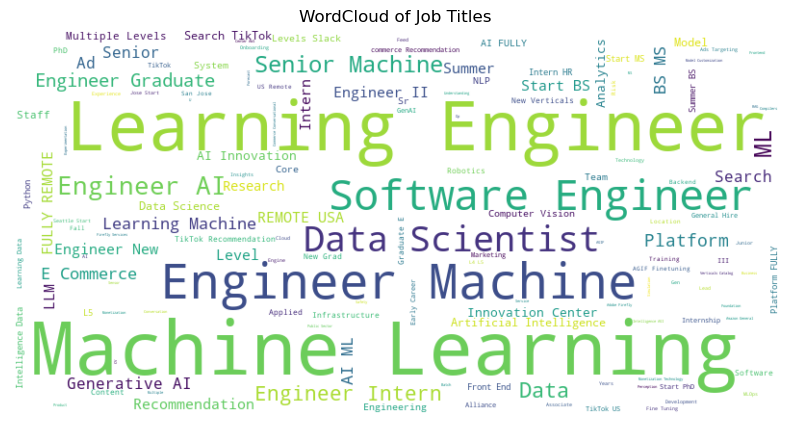

In [124]:
from wordcloud import WordCloud

text = ' '.join(df['job_title'].dropna().astype(str).tolist())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud of Job Titles")
plt.show()


In [97]:
pip install WordCloud

Note: you may need to restart the kernel to use updated packages.


In [125]:
# Convert job_posted_date to datetime
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'], errors='coerce')

# Extract features
df['job_posted_year'] = df['job_posted_date'].dt.year
df['job_posted_month'] = df['job_posted_date'].dt.month
df['job_posted_day'] = df['job_posted_date'].dt.day
df['job_posted_weekday'] = df['job_posted_date'].dt.weekday


In [126]:
df.head()

,job_posted_date,company_address_locality,company_address_region,company_name,company_website,company_description,job_description_text,seniority_level,job_title,job_posted_year,job_posted_month,job_posted_day,job_posted_weekday
0,2024-10-31,Indianapolis,Indiana,Upper Hand,https://upperhand.com,Upper Hand is the leading provider of full-sui...,OverviewUpper Hand is embarking on an exciting...,Internship,Internship - Machine Learning Engineer & Data ...,2024,10,31,3
1,2025-03-14,San Francisco,California,Ikigai,https://www.ikigailabs.io,"Built upon years of MIT research, Ikigai is a ...",Company DescriptionThe Ikigai platform unlocks...,Mid-Senior level,Machine Learning Engineer,2025,3,14,4
2,2025-04-09,San Jose,CA,Adobe,http://www.adobe.com,Adobe is the global leader in digital media an...,Our CompanyChanging the world through digital ...,Entry level,Machine Learning Engineer,2025,4,9,2
3,2025-03-22,Mountain View,California,Waymo,https://waymo.com/careers/,On the journey to be the world's most trusted ...,Waymo is an autonomous driving technology comp...,Entry level,"Machine Learning Engineer, Training",2025,3,22,5
4,2025-03-28,Boston,Massachusetts,HMH,http://www.hmhco.com,We are an adaptive learning company that empow...,Job Title: Machine Learning EngineerLocation: ...,Mid-Senior level,Machine Learning Engineer,2025,3,28,4


In [127]:
# Combine city and state
df['location'] = df['company_address_locality'] + ', ' + df['company_address_region']

# Frequency encoding for location
location_freq = df['location'].value_counts().to_dict()
df['location_freq'] = df['location'].map(location_freq)


In [128]:
df.head()

,job_posted_date,company_address_locality,company_address_region,company_name,company_website,company_description,job_description_text,seniority_level,job_title,job_posted_year,job_posted_month,job_posted_day,job_posted_weekday,location,location_freq
0,2024-10-31,Indianapolis,Indiana,Upper Hand,https://upperhand.com,Upper Hand is the leading provider of full-sui...,OverviewUpper Hand is embarking on an exciting...,Internship,Internship - Machine Learning Engineer & Data ...,2024,10,31,3,"Indianapolis, Indiana",4.0
1,2025-03-14,San Francisco,California,Ikigai,https://www.ikigailabs.io,"Built upon years of MIT research, Ikigai is a ...",Company DescriptionThe Ikigai platform unlocks...,Mid-Senior level,Machine Learning Engineer,2025,3,14,4,"San Francisco, California",105.0
2,2025-04-09,San Jose,CA,Adobe,http://www.adobe.com,Adobe is the global leader in digital media an...,Our CompanyChanging the world through digital ...,Entry level,Machine Learning Engineer,2025,4,9,2,"San Jose, CA",33.0
3,2025-03-22,Mountain View,California,Waymo,https://waymo.com/careers/,On the journey to be the world's most trusted ...,Waymo is an autonomous driving technology comp...,Entry level,"Machine Learning Engineer, Training",2025,3,22,5,"Mountain View, California",25.0
4,2025-03-28,Boston,Massachusetts,HMH,http://www.hmhco.com,We are an adaptive learning company that empow...,Job Title: Machine Learning EngineerLocation: ...,Mid-Senior level,Machine Learning Engineer,2025,3,28,4,"Boston, Massachusetts",17.0


In [129]:
# Check if job is remote
df['is_remote'] = df['job_description_text'].str.contains('remote', case=False, na=False).astype(int)

# Check if experience is required
df['mentions_experience'] = df['job_description_text'].str.contains('experience', case=False, na=False).astype(int)

# Check for 'PhD'
df['mentions_phd'] = df['job_description_text'].str.contains('phd', case=False, na=False).astype(int)


In [130]:
df.head()

,job_posted_date,company_address_locality,company_address_region,company_name,company_website,company_description,job_description_text,seniority_level,job_title,job_posted_year,job_posted_month,job_posted_day,job_posted_weekday,location,location_freq,is_remote,mentions_experience,mentions_phd
0,2024-10-31,Indianapolis,Indiana,Upper Hand,https://upperhand.com,Upper Hand is the leading provider of full-sui...,OverviewUpper Hand is embarking on an exciting...,Internship,Internship - Machine Learning Engineer & Data ...,2024,10,31,3,"Indianapolis, Indiana",4.0,0,1,0
1,2025-03-14,San Francisco,California,Ikigai,https://www.ikigailabs.io,"Built upon years of MIT research, Ikigai is a ...",Company DescriptionThe Ikigai platform unlocks...,Mid-Senior level,Machine Learning Engineer,2025,3,14,4,"San Francisco, California",105.0,0,1,0
2,2025-04-09,San Jose,CA,Adobe,http://www.adobe.com,Adobe is the global leader in digital media an...,Our CompanyChanging the world through digital ...,Entry level,Machine Learning Engineer,2025,4,9,2,"San Jose, CA",33.0,0,1,1
3,2025-03-22,Mountain View,California,Waymo,https://waymo.com/careers/,On the journey to be the world's most trusted ...,Waymo is an autonomous driving technology comp...,Entry level,"Machine Learning Engineer, Training",2025,3,22,5,"Mountain View, California",25.0,1,1,0
4,2025-03-28,Boston,Massachusetts,HMH,http://www.hmhco.com,We are an adaptive learning company that empow...,Job Title: Machine Learning EngineerLocation: ...,Mid-Senior level,Machine Learning Engineer,2025,3,28,4,"Boston, Massachusetts",17.0,1,1,0


In [131]:
df.drop(columns=['job_posted_date','company_address_locality','company_address_region'], inplace=True)


In [132]:
df.head()

,company_name,company_website,company_description,job_description_text,seniority_level,job_title,job_posted_year,job_posted_month,job_posted_day,job_posted_weekday,location,location_freq,is_remote,mentions_experience,mentions_phd
0,Upper Hand,https://upperhand.com,Upper Hand is the leading provider of full-sui...,OverviewUpper Hand is embarking on an exciting...,Internship,Internship - Machine Learning Engineer & Data ...,2024,10,31,3,"Indianapolis, Indiana",4.0,0,1,0
1,Ikigai,https://www.ikigailabs.io,"Built upon years of MIT research, Ikigai is a ...",Company DescriptionThe Ikigai platform unlocks...,Mid-Senior level,Machine Learning Engineer,2025,3,14,4,"San Francisco, California",105.0,0,1,0
2,Adobe,http://www.adobe.com,Adobe is the global leader in digital media an...,Our CompanyChanging the world through digital ...,Entry level,Machine Learning Engineer,2025,4,9,2,"San Jose, CA",33.0,0,1,1
3,Waymo,https://waymo.com/careers/,On the journey to be the world's most trusted ...,Waymo is an autonomous driving technology comp...,Entry level,"Machine Learning Engineer, Training",2025,3,22,5,"Mountain View, California",25.0,1,1,0
4,HMH,http://www.hmhco.com,We are an adaptive learning company that empow...,Job Title: Machine Learning EngineerLocation: ...,Mid-Senior level,Machine Learning Engineer,2025,3,28,4,"Boston, Massachusetts",17.0,1,1,0


In [133]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['job_title'] = le.fit_transform(df['job_title'])
df['seniority_level'] = le.fit_transform(df['seniority_level'])
df['location'] = le.fit_transform(df['location'])


In [135]:
df.head()

,company_name,company_website,company_description,job_description_text,seniority_level,job_title,job_posted_year,job_posted_month,job_posted_day,job_posted_weekday,location,location_freq,is_remote,mentions_experience,mentions_phd
0,Upper Hand,https://upperhand.com,Upper Hand is the leading provider of full-sui...,OverviewUpper Hand is embarking on an exciting...,4,84,2024,10,31,3,87,4.0,0,1,0
1,Ikigai,https://www.ikigailabs.io,"Built upon years of MIT research, Ikigai is a ...",Company DescriptionThe Ikigai platform unlocks...,5,110,2025,3,14,4,170,105.0,0,1,0
2,Adobe,http://www.adobe.com,Adobe is the global leader in digital media an...,Our CompanyChanging the world through digital ...,2,110,2025,4,9,2,171,33.0,0,1,1
3,Waymo,https://waymo.com/careers/,On the journey to be the world's most trusted ...,Waymo is an autonomous driving technology comp...,2,288,2025,3,22,5,124,25.0,1,1,0
4,HMH,http://www.hmhco.com,We are an adaptive learning company that empow...,Job Title: Machine Learning EngineerLocation: ...,5,110,2025,3,28,4,22,17.0,1,1,0


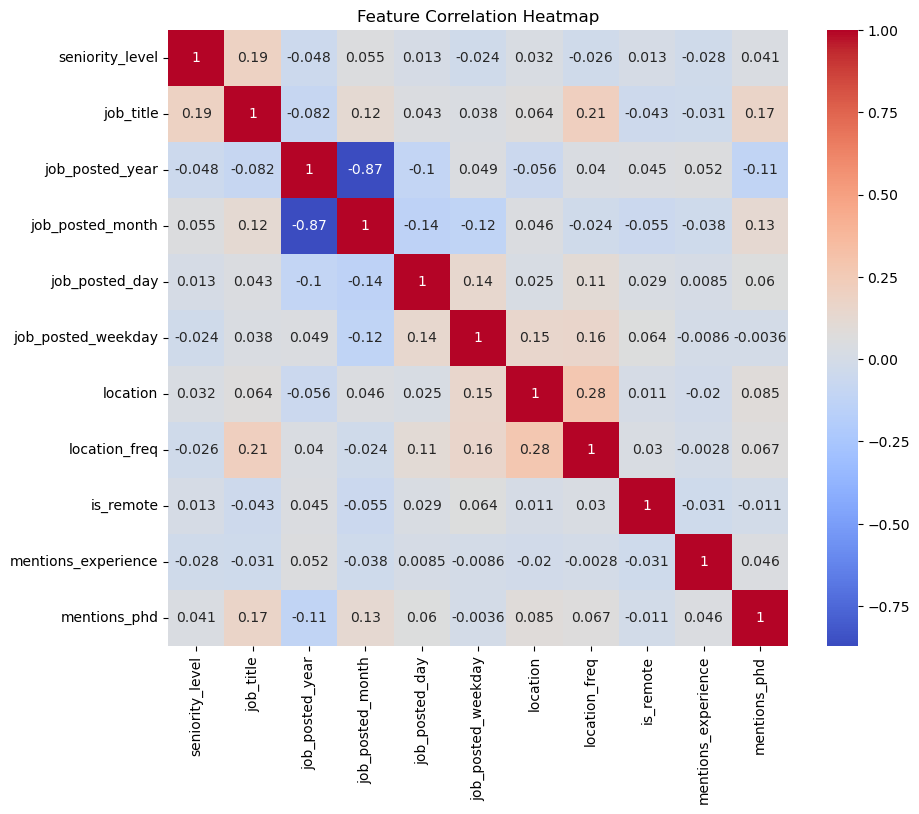

In [136]:
import seaborn as sns
import matplotlib.pyplot as plt

# If you have a target variable (e.g., salary, is_remote, etc.)
# Correlation with is_remote as example target
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


In [137]:
df.head()

,company_name,company_website,company_description,job_description_text,seniority_level,job_title,job_posted_year,job_posted_month,job_posted_day,job_posted_weekday,location,location_freq,is_remote,mentions_experience,mentions_phd
0,Upper Hand,https://upperhand.com,Upper Hand is the leading provider of full-sui...,OverviewUpper Hand is embarking on an exciting...,4,84,2024,10,31,3,87,4.0,0,1,0
1,Ikigai,https://www.ikigailabs.io,"Built upon years of MIT research, Ikigai is a ...",Company DescriptionThe Ikigai platform unlocks...,5,110,2025,3,14,4,170,105.0,0,1,0
2,Adobe,http://www.adobe.com,Adobe is the global leader in digital media an...,Our CompanyChanging the world through digital ...,2,110,2025,4,9,2,171,33.0,0,1,1
3,Waymo,https://waymo.com/careers/,On the journey to be the world's most trusted ...,Waymo is an autonomous driving technology comp...,2,288,2025,3,22,5,124,25.0,1,1,0
4,HMH,http://www.hmhco.com,We are an adaptive learning company that empow...,Job Title: Machine Learning EngineerLocation: ...,5,110,2025,3,28,4,22,17.0,1,1,0


In [138]:
df.drop(columns=['company_website','company_description','job_description_text'], inplace=True)

In [139]:
# Frequency encoding
df['company_name_encoded'] = df['company_name'].map(df['company_name'].value_counts())
df.head()

,company_name,seniority_level,job_title,job_posted_year,job_posted_month,job_posted_day,job_posted_weekday,location,location_freq,is_remote,mentions_experience,mentions_phd,company_name_encoded
0,Upper Hand,4,84,2024,10,31,3,87,4.0,0,1,0,1
1,Ikigai,5,110,2025,3,14,4,170,105.0,0,1,0,1
2,Adobe,2,110,2025,4,9,2,171,33.0,0,1,1,18
3,Waymo,2,288,2025,3,22,5,124,25.0,1,1,0,11
4,HMH,5,110,2025,3,28,4,22,17.0,1,1,0,1


In [140]:
df.drop(columns=['company_name'], inplace=True)

In [141]:
df.head()

,seniority_level,job_title,job_posted_year,job_posted_month,job_posted_day,job_posted_weekday,location,location_freq,is_remote,mentions_experience,mentions_phd,company_name_encoded
0,4,84,2024,10,31,3,87,4.0,0,1,0,1
1,5,110,2025,3,14,4,170,105.0,0,1,0,1
2,2,110,2025,4,9,2,171,33.0,0,1,1,18
3,2,288,2025,3,22,5,124,25.0,1,1,0,11
4,5,110,2025,3,28,4,22,17.0,1,1,0,1


In [ ]:
target = 'is_remote'
X = df.drop(columns=[target])
y = df[target]

Top 10 Important Features:
 company_name_encoded    0.168027
job_title               0.167068
location                0.165540
location_freq           0.133475
job_posted_day          0.116457
job_posted_weekday      0.083239
seniority_level         0.072276
job_posted_month        0.053821
mentions_phd            0.024829
job_posted_year         0.008514
mentions_experience     0.006754
dtype: float64


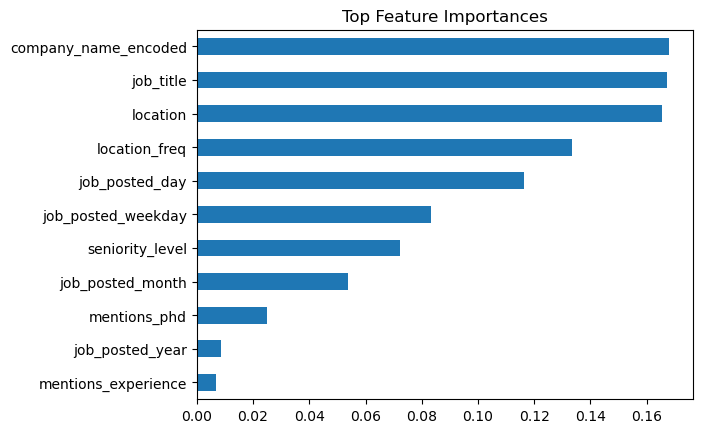

In [146]:
from sklearn.ensemble import RandomForestClassifier

# Train a Random Forest (example target: is_remote)
model = RandomForestClassifier()
model.fit(X, y)

# Get feature importances
importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(12)
print("Top 10 Important Features:\n", top_features)

# Plot
top_features.plot(kind='barh')
plt.title("Top Feature Importances")
plt.gca().invert_yaxis()
plt.show()


In [147]:
X.drop(columns=['mentions_experience','job_posted_year'], inplace=True)

In [149]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Accuracy: 0.795


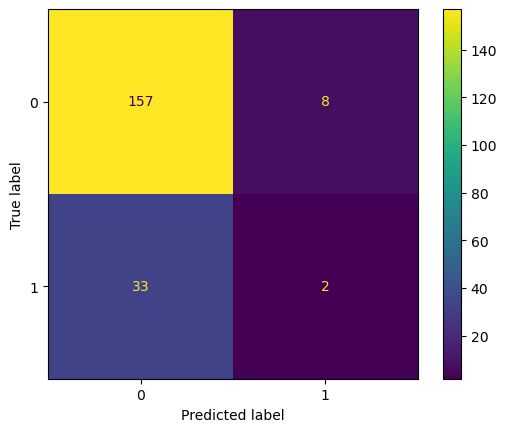

In [151]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression

# Create a pipeline that imputes missing values and then fits logistic regression
model = make_pipeline(SimpleImputer(strategy='most_frequent'), LogisticRegression(max_iter=1000))

model.fit(X_train, y_train)

# Predict and print accuracy
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
print("Accuracy:", accuracy_score(y_test, y_pred))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()


KNN Accuracy: 0.8300


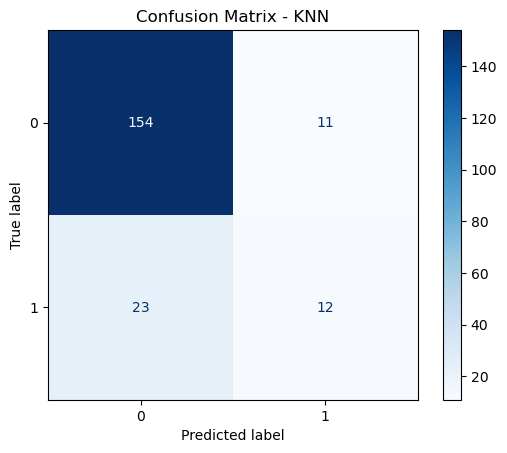

Decision Tree Accuracy: 0.8200


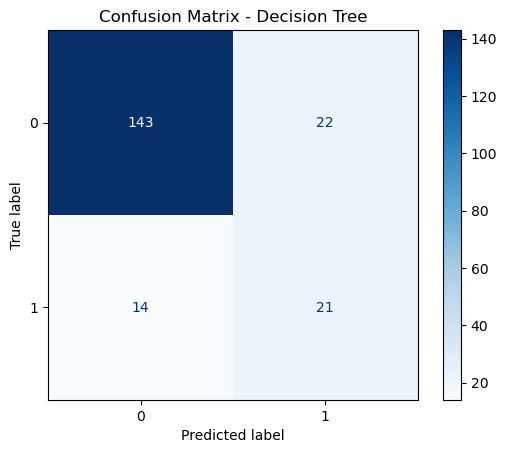

Naive Bayes Accuracy: 0.4150


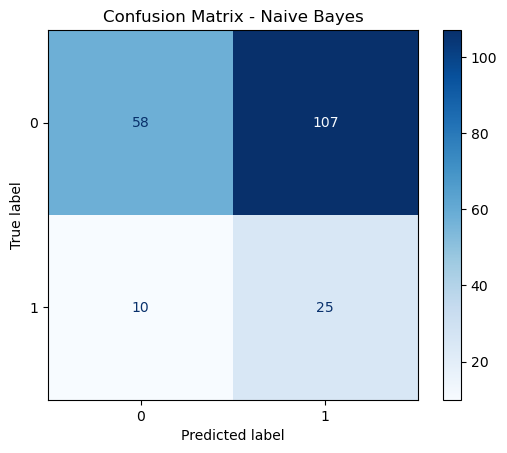

In [152]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = {
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB()
}

for name, model in models.items():
    # Create pipeline with imputer + model
    pipeline = make_pipeline(SimpleImputer(strategy='most_frequent'), model)
    
    # Fit model
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    
    # Print accuracy
    print(f"{name} Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    
    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - {name}")
    plt.show()


In [155]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Random Forest Accuracy: 0.875
[[158   7]
 [ 18  17]]


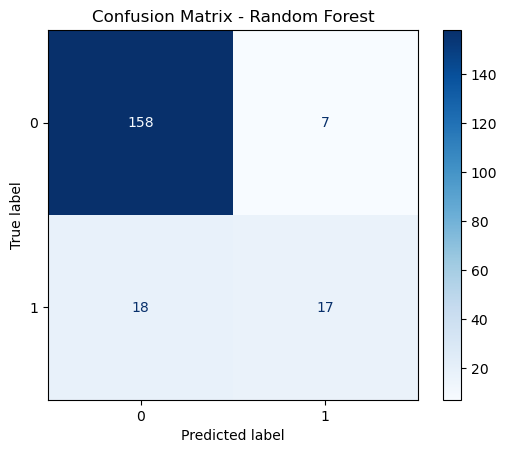

In [156]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on test set
y_pred = rf.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix with labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.title("Confusion Matrix - Random Forest")
plt.show()


What is ROC and AUC?
ROC Curve plots True Positive Rate (Recall) vs. False Positive Rate at various classification thresholds.

AUC measures the overall ability of the model to discriminate between positive and negative classes.

AUC ranges from 0 to 1:

1.0 means perfect classification.

0.5 means random guessing.

Closer to 1 is better.

In [157]:
from sklearn.metrics import roc_auc_score

y_prob = rf.predict_proba(X_test)[:, 1]  # probability for class 1 (remote)
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_prob))


Random Forest ROC-AUC: 0.8241558441558442


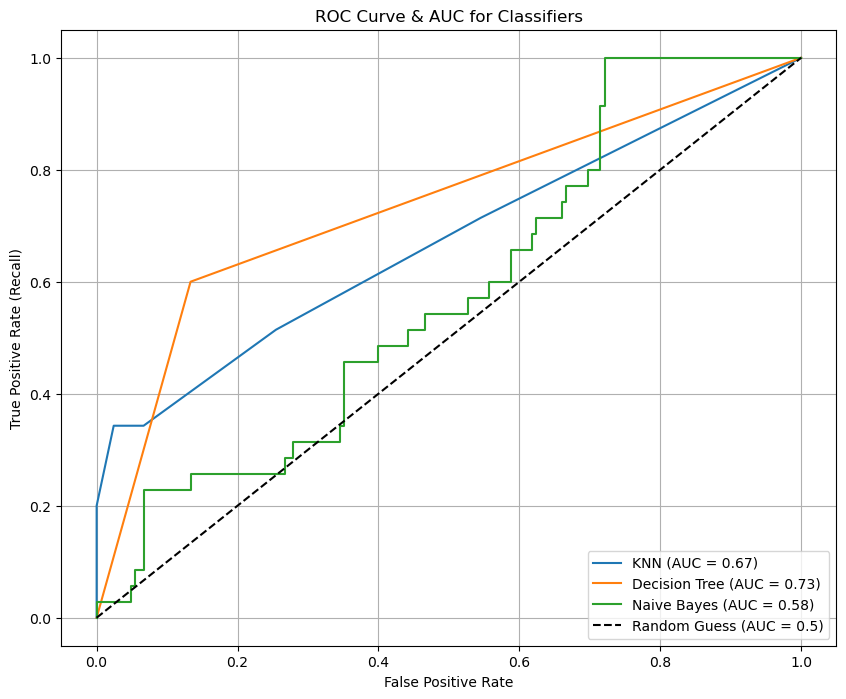

In [158]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

plt.figure(figsize=(10, 8))

for name, model in models.items():
    # Pipeline with imputer + model
    pipeline = make_pipeline(SimpleImputer(strategy='most_frequent'), model)
    pipeline.fit(X_train, y_train)

    # Predict probabilities of the positive class
    if hasattr(pipeline, "predict_proba"):
        y_probs = pipeline.predict_proba(X_test)[:, 1]
    else:
        # Some models don't have predict_proba, try decision_function
        y_probs = pipeline.decision_function(X_test)
    
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_probs, pos_label=pipeline.classes_[1])
    roc_auc = auc(fpr, tpr)
    
    # Plot ROC curve
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Plot diagonal line for random guess
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess (AUC = 0.5)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve & AUC for Classifiers")
plt.legend(loc="lower right")
plt.grid()
plt.show()
